# Demo 3 — Classify a photo

_Section 3: Image Classification._

Classification answers one question: **"What is in this image?"** We'll feed the photo to a trained classifier, read off its **top guesses with confidences**, then tweak the input and watch the predictions change.

In [1]:
import warnings

import cv2
import matplotlib.pyplot as plt
from PIL import Image
from transformers import pipeline
from transformers.utils import logging

warnings.filterwarnings("ignore")
logging.set_verbosity_error()

IMG_PATH = "demo.jpg"  # the shared image used across all demos

/Users/mahyoubm/Documents/adhoc/cv-intro/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
objc[70889]: Class AVFFrameReceiver is implemented in both /Users/mahyoubm/Documents/adhoc/cv-intro/.venv/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1085d43a8) and /Users/mahyoubm/Documents/adhoc/cv-intro/.venv/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.3.102.dylib (0x126dfc3a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[70889]: Class AVFAudioReceiver is implemented in both /Users/mahyoubm/Documents/adhoc/cv-intro/.venv/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1085d43f8) and /Users/mahyoubm/Documents/adhoc/cv-intro/.venv/lib/python3.12/site-packages/av/.dylibs/liba

## 1. Load the image and a trained classifier

We read the image with OpenCV (BGR → RGB) and wrap it as a PIL image for the model.
The model is **ResNet-50**, a convolutional network trained on **ImageNet** (1000 everyday categories).

In [2]:
bgr = cv2.imread(IMG_PATH)                    # OpenCV loads as BGR
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)    # -> RGB
image = Image.fromarray(rgb)                  # transformers wants a PIL image

classifier = pipeline("image-classification", model="microsoft/resnet-50")
print("Loaded ResNet-50 — trained on 1000 ImageNet classes.")

Loading weights: 100%|██████████| 320/320 [00:00<00:00, 13052.26it/s]


Loaded ResNet-50 — trained on 1000 ImageNet classes.


## 2. Ask the model: "What is in this image?"

The classifier returns a **probability for every possible label**. We show the top 5.

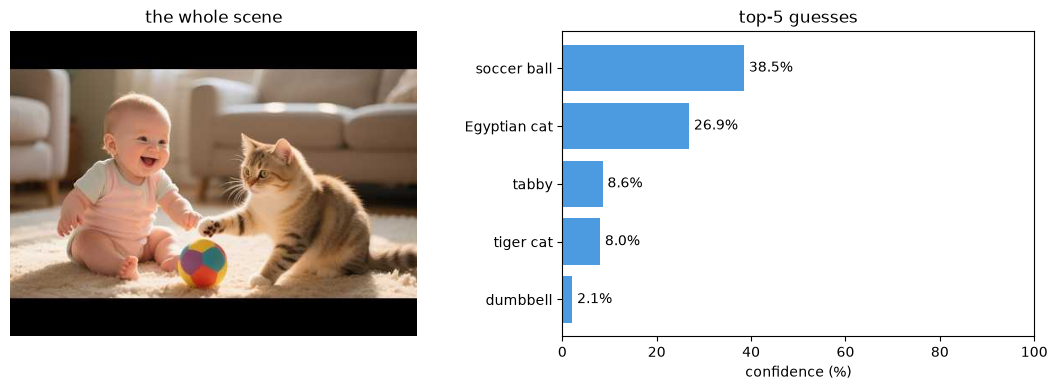

In [3]:
def show_predictions(img, title="", k=5):
    """Classify an image and show it beside a bar chart of the top-k guesses."""
    preds = classifier(img, top_k=k)
    labels = [p["label"].split(",")[0] for p in preds][::-1]  # short label, low->high
    scores = [p["score"] * 100 for p in preds][::-1]

    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].imshow(img)
    ax[0].axis("off")
    ax[0].set_title(title or "input")

    ax[1].barh(labels, scores, color="#4C9BE0")
    ax[1].set_xlim(0, 100)
    ax[1].set_xlabel("confidence (%)")
    ax[1].set_title(f"top-{k} guesses")
    for i, s in enumerate(scores):
        ax[1].text(s + 1, i, f"{s:.1f}%", va="center")
    plt.tight_layout()
    plt.show()
    return preds


_ = show_predictions(image, "the whole scene")

Notice the model is **torn**: it splits its confidence between the *ball* and the *cat*, because it must pick **one** label for a scene that contains several things.

> Also note: there's no "baby" or "person" class in ImageNet's 1000 categories — the model can only answer with words it was taught.

## 3. Tweak the input, watch the predictions change

If we crop to a **single object**, the classifier gets much more confident.

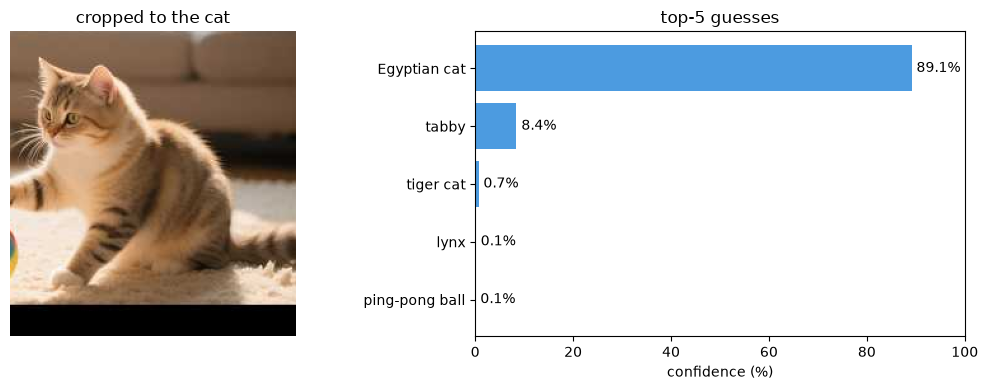

In [4]:
# crop box = (left, upper, right, lower)
cat = image.crop((250, 100, 475, 340))
_ = show_predictions(cat, "cropped to the cat")

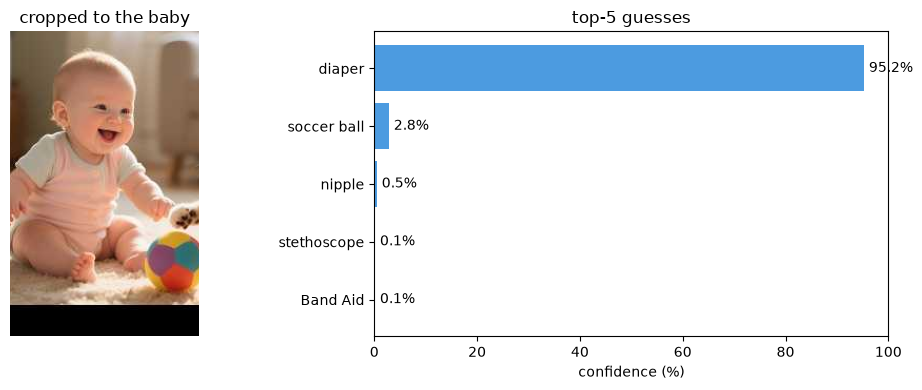

In [5]:
baby = image.crop((70, 55, 250, 345))
_ = show_predictions(baby, "cropped to the baby")

The cat crop is now confidently a **cat**, and the baby crop becomes... **"diaper"** — the closest word the model knows. Same pixels, different framing, different answer.

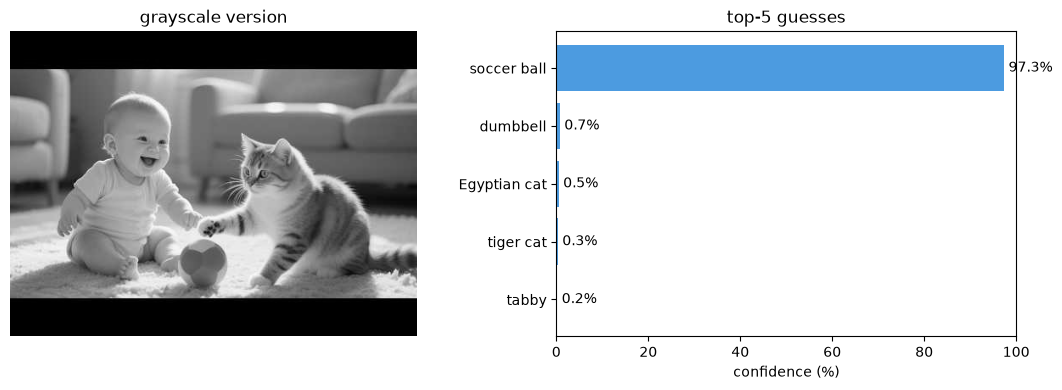

In [6]:
# Another tweak: strip the color out entirely.
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
gray_rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)  # 3 identical channels
_ = show_predictions(Image.fromarray(gray_rgb), "grayscale version")

## Takeaway

A classifier gives **one label for the whole image** — useful, but limited. It can't tell us *which* cat, *where* the ball is, or that there's a baby too.

To answer **"what objects are here, and where?"** we need the next task: **object detection**.